In [31]:
# Importing libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [2]:
from tensorflow.keras import datasets,layers,models
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Dataset Loading

In [3]:
(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()

In [4]:
x_test.shape

(10000, 32, 32, 3)

In [5]:
x_train.shape

(50000, 32, 32, 3)

In [6]:
y_train.shape

(50000, 1)

In [7]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [ ]:
#Label Reshaping

In [8]:
y_train=y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [9]:
y_test=y_test.reshape(-1,)

In [10]:
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [11]:
def plot_sample(x,y,index):
    plt.figure(figsize=(15,2))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index]])

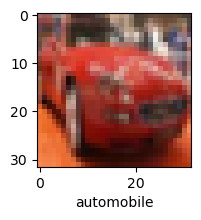

In [12]:
plot_sample(x_train,y_train,5)


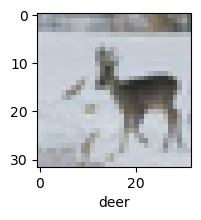

In [13]:
plot_sample(x_train,y_train,20)


In [ ]:
#Data Normalization

In [14]:
x_train=x_train/255.0
x_test=x_test/255.0

In [ ]:
#ANN Model

In [ ]:
ann=models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Flatten(),
    layers.Dense(3000,activation="relu"),
    layers.Dense(1000,activation="relu"),
    layers.Dense(10,activation="softmax"),

])

ann.compile(optimizer="SGD",
           loss="sparse_categorical_crossentropy",
           metrics=["accuracy"])

ann.fit(x_train,y_train,epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 238s 146ms/step - accuracy: 0.3520 - loss: 1.8119
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 220s 141ms/step - accuracy: 0.4262 - loss: 1.6246
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 221s 141ms/step - accuracy: 0.4579 - loss: 1.5396
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 256s 137ms/step - accuracy: 0.4789 - loss: 1.4797
Epoch 5/5
1185/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 147ms/step - accuracy: 0.4907 - loss: 1.4447

In [17]:
from sklearn.metrics import confusion_matrix,classification_report
y_pred=ann.predict(x_test)
y_pred_classes=[np.argmax(element) for element in y_pred]


print("Classification report:\n",classification_report(y_test,y_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 75ms/step
Classification report:
               precision    recall  f1-score   support

           0       0.64      0.41      0.50      1000
           1       0.67      0.56      0.61      1000
           2       0.44      0.21      0.29      1000
           3       0.27      0.55      0.36      1000
           4       0.60      0.15      0.24      1000
           5       0.43      0.28      0.34      1000
           6       0.37      0.78      0.50      1000
           7       0.66      0.42      0.52      1000
           8       0.52      0.75      0.62      1000
           9       0.56      0.56      0.56      1000

    accuracy                           0.47     10000
   macro avg       0.52      0.47      0.45     10000
weighted avg       0.52      0.47      0.45     10000



In [18]:
import seaborn as sns

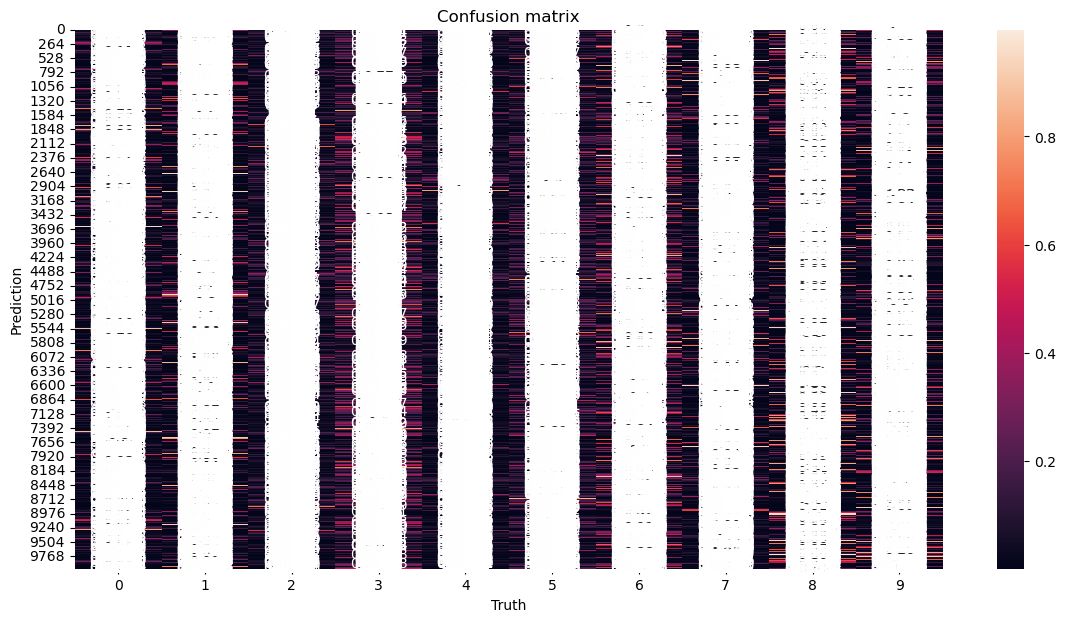

In [23]:
plt.figure(figsize=(14,7))
sns.heatmap(y_pred,annot=True)
plt.xlabel("Truth")
plt.ylabel("Prediction")
plt.title("Confusion matrix")
plt.show()

In [ ]:
#CNN Model

In [28]:
model = keras.Sequential([
    keras.Input(shape=(32,32,3)),
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])




In [ ]:
#compile model

In [29]:
model.compile(optimizer="adam",
           loss="sparse_categorical_crossentropy",
           metrics=["accuracy"])

In [ ]:
#Train model

In [32]:
model.fit(x_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 227s 145ms/step - accuracy: 0.7698 - loss: 0.6594
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 126ms/step - accuracy: 0.7803 - loss: 0.6300
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 212s 133ms/step - accuracy: 0.7882 - loss: 0.6039
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 222s 107ms/step - accuracy: 0.7971 - loss: 0.5783
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 235s 150ms/step - accuracy: 0.8038 - loss: 0.5562
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 231s 130ms/step - accuracy: 0.8121 - loss: 0.5345
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 502s 92ms/step - accuracy: 0.8166 - loss: 0.5171
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.8252 - loss: 0.4972
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.8304 - loss: 0.4798
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 93ms/step - accuracy: 0.8364 - loss: 0.4617


In [ ]:
#Evalute model

In [33]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6932 - loss: 1.0616


[1.0616155862808228, 0.6931999921798706]

In [34]:
#prediction

In [36]:
y_pred=model.predict(x_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


array([[1.93784626e-06, 3.16083861e-05, 1.00939756e-03, 9.42614794e-01,
        2.90307304e-04, 4.38410155e-02, 1.13629177e-02, 2.15361126e-07,
        3.31721298e-04, 5.16037806e-04],
       [3.02047056e-06, 1.29623408e-03, 4.59956828e-09, 7.31388283e-11,
        9.02058983e-11, 2.87523857e-13, 4.41153190e-11, 1.83106297e-14,
        9.98700380e-01, 3.33648103e-07],
       [1.15818195e-01, 3.58426347e-02, 6.61997264e-03, 2.25771582e-04,
        4.20895172e-04, 2.20808244e-04, 9.10742347e-06, 3.07489827e-04,
        8.37992966e-01, 2.54231179e-03],
       [9.84118342e-01, 2.45289353e-04, 5.13456715e-03, 3.23126820e-04,
        5.22460869e-05, 1.50974256e-06, 7.73052016e-05, 1.54140287e-06,
        1.00195473e-02, 2.66180596e-05],
       [1.81360782e-09, 5.36968491e-06, 1.31192338e-03, 1.16526131e-02,
        3.22256416e-01, 9.80116238e-06, 6.64763272e-01, 6.71043221e-09,
        5.64110962e-07, 2.05300943e-10]], dtype=float32)

In [37]:
y_classes=[np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [38]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

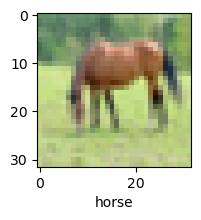

In [39]:
plot_sample(x_test,y_test,60)

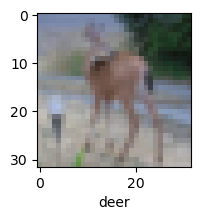

In [40]:
plot_sample(x_test,y_test,100)

In [41]:
classes[y_classes[60]]

'horse'

In [42]:
classes[y_classes[4]]

'frog'

In [ ]:
#save model

In [47]:
model.save("cnn_image_classifier.keras")
